In [3]:
import re
string = """Alameda
Albany
American Canyon
Antioch
Atherton
Belmont
Belvedere
Benicia
Berkeley
Brisbane
Burlingame
Campbell
Clayton
Colma
Concord
Corte Madera
Cupertino
Daly City
Danville
Dublin
East Palo Alto
El Cerrito
Emeryville
Fairfax
Foster City
Fremont
Gilroy
Half Moon Bay
Hayward
Healdsburg
Hercules
Hillsborough
Lafayette
Larkspur
Livermore
Los Altos
Los Altos Hills
Los Gatos
Martinez
Menlo Park
Mill Valley
Millbrae
Milpitas
Moraga
Morgan Hill
Mountain View
Newark
Novato
Oakland
Oakley
Orinda
Pacifica
Palo Alto
Petaluma
Piedmont
Pinole
Pittsburg
Pleasanton
Pleasant Hill
Port Costa
Redwood City
Richmond
Rohnert Park
Ross
Helena
San Anselmo
San Bruno
San Carlos
San Francisco
San Jose
San Leandro
San Mateo
San Pablo
San Rafael
San Ramon
Santa Clara
Santa Rosa
Saratoga
Sausalito
Sebastopol
Sonoma
South San Francisco
Suisun City
Sunnyvale
Tiburon
Union City
Vallejo
Walnut Creek
Windsor
Woodside"""

locs = re.split(r'\n', string)
locs

['Alameda',
 'Albany',
 'American Canyon',
 'Antioch',
 'Atherton',
 'Belmont',
 'Belvedere',
 'Benicia',
 'Berkeley',
 'Brisbane',
 'Burlingame',
 'Campbell',
 'Clayton',
 'Colma',
 'Concord',
 'Corte Madera',
 'Cupertino',
 'Daly City',
 'Danville',
 'Dublin',
 'East Palo Alto',
 'El Cerrito',
 'Emeryville',
 'Fairfax',
 'Foster City',
 'Fremont',
 'Gilroy',
 'Half Moon Bay',
 'Hayward',
 'Healdsburg',
 'Hercules',
 'Hillsborough',
 'Lafayette',
 'Larkspur',
 'Livermore',
 'Los Altos',
 'Los Altos Hills',
 'Los Gatos',
 'Martinez',
 'Menlo Park',
 'Mill Valley',
 'Millbrae',
 'Milpitas',
 'Moraga',
 'Morgan Hill',
 'Mountain View',
 'Newark',
 'Novato',
 'Oakland',
 'Oakley',
 'Orinda',
 'Pacifica',
 'Palo Alto',
 'Petaluma',
 'Piedmont',
 'Pinole',
 'Pittsburg',
 'Pleasanton',
 'Pleasant Hill',
 'Port Costa',
 'Redwood City',
 'Richmond',
 'Rohnert Park',
 'Ross',
 'Helena',
 'San Anselmo',
 'San Bruno',
 'San Carlos',
 'San Francisco',
 'San Jose',
 'San Leandro',
 'San Mateo',
 'S

In [6]:
new_loc = []
for loc in locs: 
    add = "\"" + loc + ", CA\""
    new_loc.append(add)

In [1]:
import pandas as pd
import numpy as np
bay_matcha_df = pd.read_csv(r'C:\Users\izlal\matcha\data\bay_area_matcha.csv')
print(bay_matcha_df['reviews'].describe())
print("median: ", bay_matcha_df['reviews'].median())
print("70%: ", bay_matcha_df['reviews'].quantile(0.7))

count    2152.000000
mean      224.883364
std       357.376503
min         0.000000
25%        31.750000
50%       114.000000
75%       265.000000
max      6122.000000
Name: reviews, dtype: float64
median:  114.0
70%:  216.0


Text(0.5, 0, 'Number of Reviews')

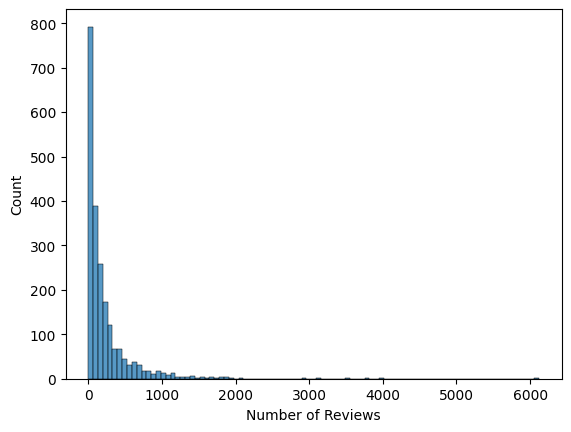

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data = bay_matcha_df, x = 'reviews')
plt.xlabel('Number of Reviews')
## visualize review numbers skew

Want to weight ratings by review number. Calculated weighted ratings with Bayesian average. Min review threshold = 70th percentile (227)

Text(0.5, 0, 'Number of Reviews')

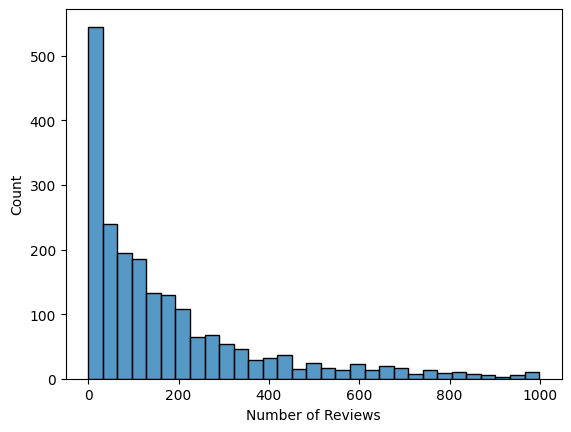

In [25]:
bay_matcha_df_zoom = bay_matcha_df[bay_matcha_df['reviews'] <= 1000]
sns.histplot(data = bay_matcha_df_zoom, x = 'reviews')
plt.xlabel('Number of Reviews')

Text(0.5, 0, 'Number of Reviews')

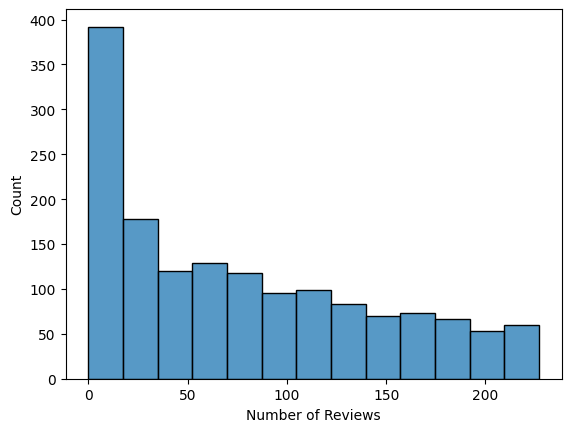

In [26]:
bay_matcha_df_zoomer = bay_matcha_df[bay_matcha_df['reviews'] <= 227]
sns.histplot(data = bay_matcha_df_zoomer, x = 'reviews')
plt.xlabel('Number of Reviews')

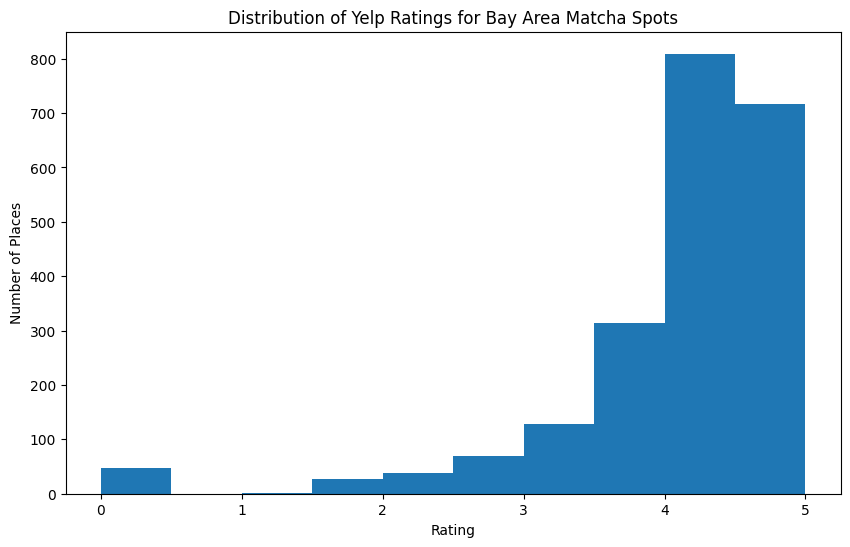

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(bay_matcha_df["rating"], bins=10)
plt.title("Distribution of Yelp Ratings for Bay Area Matcha Spots")
plt.xlabel("Rating")
plt.ylabel("Number of Places")
plt.show()

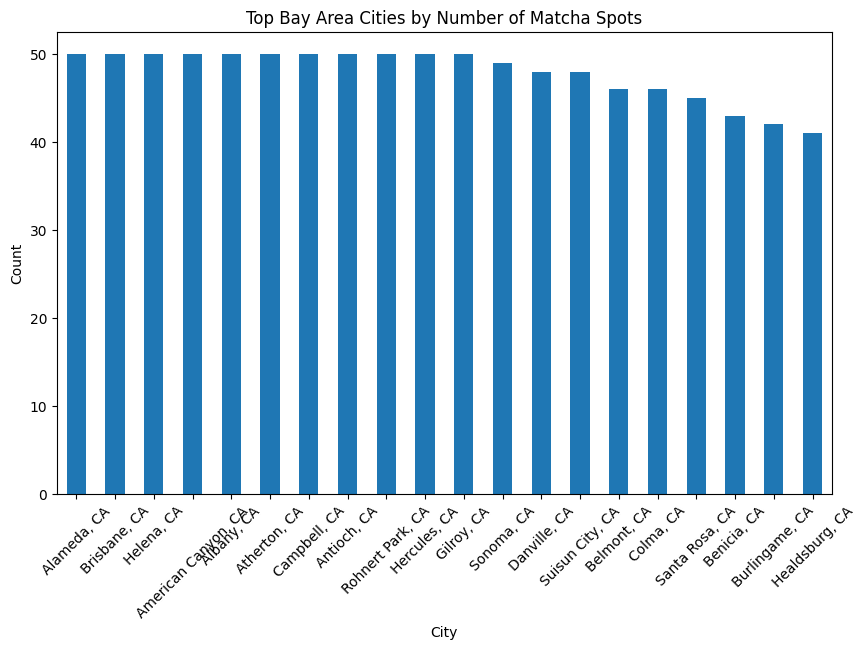

In [6]:
city_counts = bay_matcha_df["location_query"].value_counts().head(20)

plt.figure(figsize=(10,6))
city_counts.plot(kind="bar")
plt.title("Top Bay Area Cities by Number of Matcha Spots")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

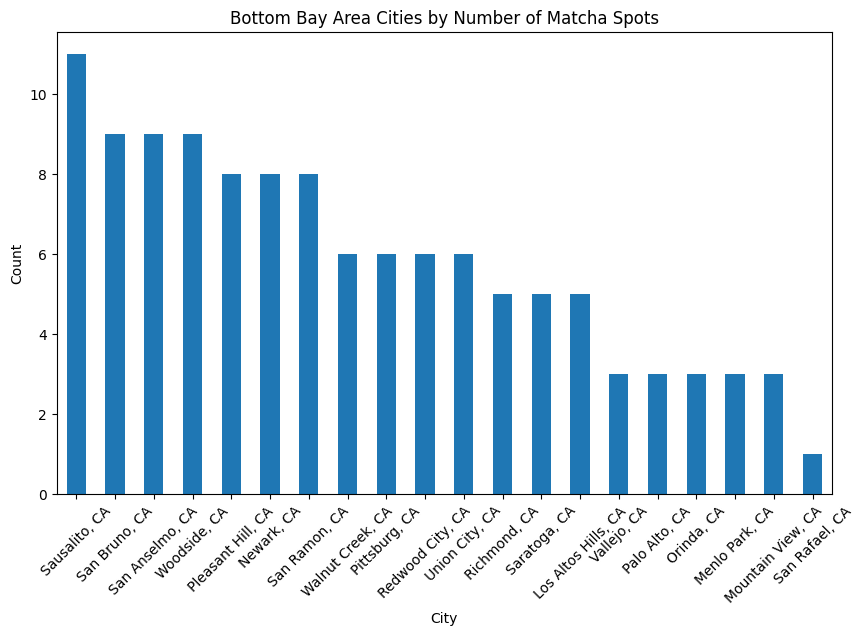

In [8]:
city_counts = bay_matcha_df["location_query"].value_counts().tail(20)

plt.figure(figsize=(10,6))
city_counts.plot(kind="bar")
plt.title("Bottom Bay Area Cities by Number of Matcha Spots")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

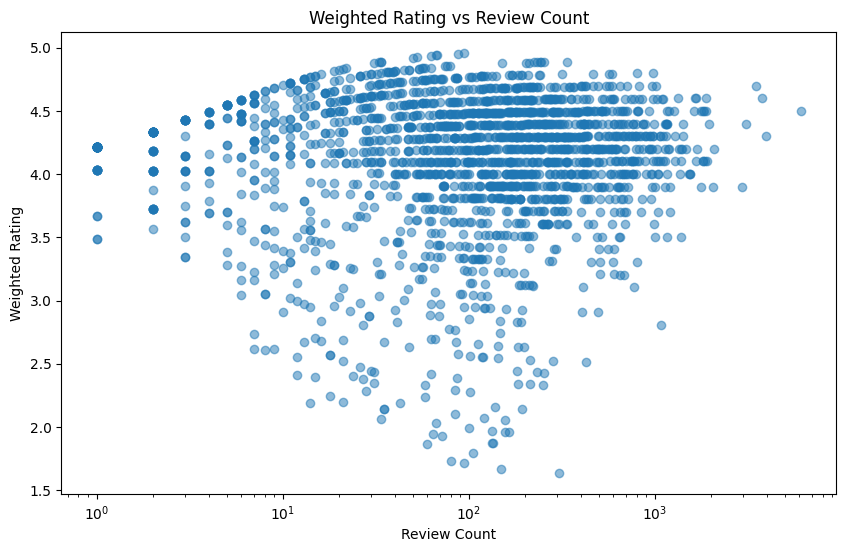

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(bay_matcha_df["reviews"], bay_matcha_df["weighted_rating"], alpha=0.5)

plt.title("Weighted Rating vs Review Count")
plt.xlabel("Review Count")
plt.ylabel("Weighted Rating")
plt.xscale("log")
plt.show()